In [1]:
#Installing necessary libraries

%pip install control > NUL
%pip install matplotlib > NUL
%pip install numpy > NUL

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [40]:
import control as ctrl
from math import exp, sqrt, sin
import matplotlib.pyplot as plt
import numpy as np

#Declaration of system constants/parameters

s = ctrl.TransferFunction.s

m = 0.462
g = 9.81
d = 0.42
delta = 0.65
r = 0.123
R = 2200
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c_val = 6.811
k = 1885
b = 10.4
tau = 0.03
phi = np.deg2rad(41)

x_1e = 0.5
x_2e = 0
x_3e = (delta - x_1e)*sqrt( (k*(x_1e-d) - m*g*sin(phi)) / c_val)


a_3 = (5/(7*m)) * (2*c_val*x_3e)/((delta - x_1e)**2) #x3
a_2 = (5/(7*m))*(-b) #x2
a_1 = (5/(7*m)) * ( (2*c_val*(x_3e**2) ) / ( (delta - x_1e)**3 )  -k) #x1

b_1 = 1/ (L0 + L1*exp(-alpha*(delta - x_1e)))
b_2 = -R/ (L0 + L1*exp(-alpha*(delta - x_1e)))

Gm = a_3/(s**2 - a_2*s - a_1)
Ge = b_1/(s - b_2)
Gs = (1)/((tau*s)+1)

Gme = Gm*Ge

Modelling a 1 N mechanical disturbance (wind blowing, human interference etc.)

c:\Users\Kairl Lau\anaconda3\Lib\site-packages\control\timeresp.py:2015: UserWarning: System has direct feedthrough: `D != 0`. The infinite impulse at `t=0` does not appear in the output.
Results may be meaningless!
  warnings.warn("System has direct feedthrough: `D != 0`. The "


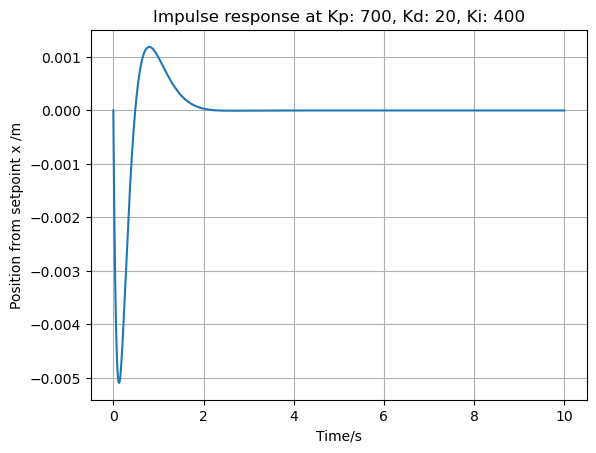

Max: 0.001 m 
Min: -0.005 m
Maximum overshoot: 0.010%


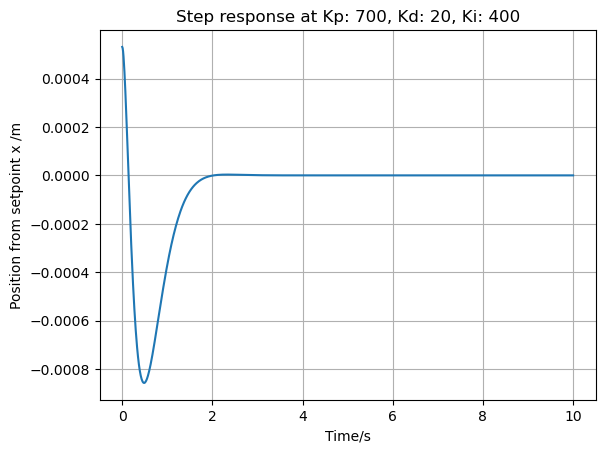

Max: 0.0005 m 
Min: -0.0009 m
Maximum overshoot: 0.0017%


Poles:
(-15158.83494908464+0j)
(-33.65745792514804+0j)
(-9.669235696033608+0j)
(-3.0363551680186505+1.7209939850919282j)
(-3.0363551680186505-1.7209939850919282j)

Stable!


In [52]:
#Testing Impulse and step responses of our completed controller but for force disturbance

Kp = 700
Kd = 20
Ki = 400

Gc = Kp + Ki/s + Kd*s
Gload = ctrl.feedback(1, Gs*Gme*Gc)

#1 N force disturbance is equivalent to 1/k metres of position disturbance, so the system response is scaled by 1/k to convert from Newtons to metres.
Newtons_to_metres = 1/k

#Impulse response

time,xs = ctrl.impulse_response(Gload, timepts=np.linspace(0, 10, 1000))
plt.plot(time, xs*Newtons_to_metres)
plt.title(f"Impulse response at Kp: {Kp}, Kd: {Kd}, Ki: {Ki}")
plt.xlabel("Time/s")
plt.ylabel("Position from setpoint x /m")
plt.grid()
plt.show()

impulse_response_max_value = max(xs*Newtons_to_metres)
impulse_response_min_value = min(xs*Newtons_to_metres)
impulse_response_max_overshoot = max( abs(impulse_response_max_value) , abs(impulse_response_min_value) )

print(f"Max: {impulse_response_max_value:.3f} m \nMin: {impulse_response_min_value:.3f} m")
print(f"Maximum overshoot: {(impulse_response_max_overshoot / x_1e):.3f}%")


#Step response

time,xs = ctrl.step_response(Gload, timepts=np.linspace(0, 10, 1000))
plt.plot(time, xs*Newtons_to_metres)
plt.title(f"Step response at Kp: {Kp}, Kd: {Kd}, Ki: {Ki}")
plt.xlabel("Time/s")
plt.ylabel("Position from setpoint x /m")
plt.grid()
plt.show()

step_response_max_value = max(xs*Newtons_to_metres)
step_response_min_value = min(xs*Newtons_to_metres)
step_response_max_overshoot = max( abs(step_response_max_value) , abs(step_response_min_value) )

print(f"Max: {step_response_max_value:.4f} m \nMin: {step_response_min_value:.4f} m")
print(f"Maximum overshoot: {(step_response_max_overshoot / x_1e):.4f}%\n\n")


#verification of BIBO stability

poles = ctrl.poles(Gload)
print("Poles:")
for pole in poles:
  print(pole)

if all(pole in poles < 0):
  print("\nStable!")



In [53]:
#Testing Impulse and step responses of our completed controller but for sensor misread of 1cm. Sensor misread is placed before Gs

Kp = 700
Kd = 20
Ki = 400

Gc = Kp + Ki/s + Kd * s 
Gload = ctrl.feedback(-Gc* Gs*Gme,1)

poles = ctrl.poles(Gload)

if not all(pole.real < 0 for pole in poles):
    print("\nUnstable!")
else:
  #Impulse response
  time,xs = ctrl.impulse_response(Gload, timepts=np.linspace(0, 10, 1000))
  plt.plot(time, xs*0.01)
  plt.title(f"Impulse response at Kp: {Kp}, Kd: {Kd}, Ki: {Ki}")
  plt.xlabel("Time/s")
  plt.ylabel("Position from setpoint x /m")
  plt.grid()
  plt.show()

  impulse_response_max_value = max(xs*0.01)
  impulse_response_min_value = min(xs*0.01)
  impulse_response_max_overshoot = max( abs(impulse_response_max_value) , abs(impulse_response_min_value) )

  print(f"Max: {impulse_response_max_value:.3f} m \nMin: {impulse_response_min_value:.3f} m")
  print(f"Maximum overshoot: {(impulse_response_max_overshoot / x_1e):.3f}%")


  #Step response

  time,xs = ctrl.step_response(Gload, timepts=np.linspace(0, 10, 1000))
  plt.plot(time, xs*0.01)
  plt.title(f"Step response at Kp: {Kp}, Kd: {Kd}, Ki: {Ki}")
  plt.xlabel("Time/s")
  plt.ylabel("Position from setpoint x /m")
  plt.show()

  step_response_max_value = max(xs*0.01)
  step_response_min_value = min(xs*0.01)
  step_response_max_overshoot = max( abs(step_response_max_value) , abs(step_response_min_value) )


  print(f"Max: {step_response_max_value:.4f} m \nMin: {step_response_min_value:.4f} m")
  print(f"Maximum overshoot: {(step_response_max_overshoot / x_1e):.4f}%\n\n")


Unstable!


Due to the sheer nonlinearity of the dynamical system, any sensor disturbances would cause massive system instability. This can be remedied with proper calibration setup to prevent zero errors (step error) and averaging of sensor values to prevent impulse errors.